In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
from dotenv import load_dotenv
import os
import ssl
import certifi
warnings.filterwarnings("ignore")

from influxdb_client import InfluxDBClient
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

load_dotenv()
# 1. Create a clean SSL context using certifi's bundle
ssl_context = ssl.create_default_context(cafile=certifi.where())

In [2]:
# connect to influxDB
url    = "https://influx.htetarkar.online/"
token  = os.getenv("influxdb_token")  # ← fill in your token
org    = "essco"
bucket = "essco_energy_data"

client    = InfluxDBClient(url=url, token=token, org=org, ssl_context=ssl_context)
query_api = client.query_api()

In [3]:

# STEP 1: FETCH & DISPLAY RAW SOLAR DATA

solar_raw_query = f'''
from(bucket: "{bucket}")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "inverter")
  |> filter(fn: (r) => r["_field"] == "ac_power_phase_a"
            or r["_field"] == "ac_power_phase_b"
            or r["_field"] == "ac_power_phase_c"
            or r["_field"] == "inverter_run_status"
            or r["_field"] == "hardware_error_code")
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time",
                    "ac_power_phase_a",
                    "ac_power_phase_b",
                    "ac_power_phase_c",
                    "inverter_run_status",
                    "hardware_error_code"])
'''

df_solar_raw = query_api.query_data_frame(solar_raw_query)

# Parse timestamps and sort
df_solar_raw["_time"] = pd.to_datetime(df_solar_raw["_time"], utc=True)
df_solar_raw = df_solar_raw.sort_values("_time")
df_solar_raw = df_solar_raw[~df_solar_raw["_time"].duplicated(keep="first")]

# Drop metadata columns
cols_to_drop = ['result', 'table']
df_solar_raw = df_solar_raw.drop(
    columns=[c for c in cols_to_drop if c in df_solar_raw.columns]
)

# Add Thailand time
df_solar_raw['thailand_time'] = (
    df_solar_raw["_time"]
    .dt.tz_convert('Asia/Bangkok')
    .dt.strftime('%Y-%m-%d %H:%M:%S')
)

# Enforce column layout
raw_layout = [
    '_time', 'thailand_time',
    'ac_power_phase_a',
    'ac_power_phase_b',
    'ac_power_phase_c',
    'inverter_run_status',
    'hardware_error_code'
]
df_solar_raw = df_solar_raw[raw_layout].reset_index(drop=True)

# ── Audit summary (replaces the separate audit cell) ──────────────────
print("Solar Power Data Audit:")
print(f"  ac_power_phase_a : "
      f"{df_solar_raw['ac_power_phase_a'].notna().sum()} rows")
print(f"  ac_power_phase_b : "
      f"{df_solar_raw['ac_power_phase_b'].notna().sum()} rows")
print(f"  ac_power_phase_c : "
      f"{df_solar_raw['ac_power_phase_c'].notna().sum()} rows")
print()
print(f"Raw Data Matrix Shape: {df_solar_raw.shape}")
df_solar_raw.head()

Solar Power Data Audit:
  ac_power_phase_a : 1516 rows
  ac_power_phase_b : 1516 rows
  ac_power_phase_c : 1516 rows

Raw Data Matrix Shape: (1516, 7)


,_time,thailand_time,ac_power_phase_a,ac_power_phase_b,ac_power_phase_c,inverter_run_status,hardware_error_code
0,2026-05-29 05:49:35+00:00,2026-05-29 12:49:35,708.90,711.60,705.30,1.0,0.0
1,2026-05-29 05:50:35+00:00,2026-05-29 12:50:35,708.90,715.80,705.00,1.0,0.0
2,2026-05-29 05:51:35+00:00,2026-05-29 12:51:35,638.01,643.95,634.50,1.0,0.0
3,2026-05-29 05:52:35+00:00,2026-05-29 12:52:35,660.80,667.24,657.44,1.0,0.0
4,2026-05-29 05:53:35+00:00,2026-05-29 12:53:35,708.90,715.50,705.00,1.0,0.0


In [4]:
# STEP 2: RESAMPLE & CREATE SOLAR TOTAL

df_solar = df_solar_raw.copy()
df_solar["_time"] = pd.to_datetime(df_solar["_time"], utc=True)
df_solar = df_solar.set_index("_time").sort_index()

# Snap onto 5-minute grid
# ffill limit=2 means only fill gaps up to 10 minutes
df_solar = df_solar.resample('5min').mean(numeric_only=True).ffill(limit=4000)

# Drop overnight/missing gaps (NaN rows)
df_solar = df_solar.dropna(subset=[
    'ac_power_phase_a',
    'ac_power_phase_b',
    'ac_power_phase_c'
])

# Create solar total right after resampling
df_solar["solar_total_watts"] = (
    df_solar["ac_power_phase_a"] +
    df_solar["ac_power_phase_b"] +
    df_solar["ac_power_phase_c"]
)

# Add Thailand time as display column only
df_solar['thailand_time'] = (
    df_solar.index
    .tz_convert('Asia/Bangkok')
    .strftime('%Y-%m-%d %H:%M:%S')
)

print(f"Resampled Data Shape : {df_solar.shape}")
print(f"solar_total_watts created")

# Show all columns together — phases + total side by side
display_cols = [
    'thailand_time',
    'ac_power_phase_a',
    'ac_power_phase_b',
    'ac_power_phase_c',
    'solar_total_watts',        # right after the three phases
    'inverter_run_status',
    'hardware_error_code'
]
df_solar[display_cols].head()

Resampled Data Shape : (4947, 7)
solar_total_watts created


,thailand_time,ac_power_phase_a,ac_power_phase_b,ac_power_phase_c,solar_total_watts,inverter_run_status,hardware_error_code
_time,,,,,,,
2026-05-29 05:45:00+00:00,2026-05-29 12:45:00,708.900,711.600,705.300,2125.800,1.0,0.0
2026-05-29 05:50:00+00:00,2026-05-29 12:50:00,689.704,696.368,685.964,2072.036,1.0,0.0
2026-05-29 05:55:00+00:00,2026-05-29 12:55:00,783.516,789.184,783.142,2355.842,1.0,0.0
2026-05-29 06:00:00+00:00,2026-05-29 13:00:00,892.970,886.672,880.736,2660.378,1.0,0.0
2026-05-29 06:05:00+00:00,2026-05-29 13:05:00,1889.684,1882.352,1862.828,5634.864,1.0,0.0


In [5]:

# STEP 3: FETCH WEATHER DATA
# (InfluxDB current + Open-Meteo historical combined)

import requests

# Part A: Fetch from InfluxDB
weather_query = f'''
from(bucket: "{bucket}")
  |> range(start: -30d)
  |> filter(fn: (r) => r["_measurement"] == "weather")
  |> filter(fn: (r) => r["_field"] == "solar_irradiance"
            or r["_field"] == "cloud_cover"
            or r["_field"] == "ambient_temp")
  |> aggregateWindow(every: 5m, fn: mean, createEmpty: false)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> keep(columns: ["_time",
                    "solar_irradiance",
                    "cloud_cover",
                    "ambient_temp"])
'''

df_weather = query_api.query_data_frame(weather_query)
df_weather["_time"] = pd.to_datetime(df_weather["_time"], utc=True)
df_weather = df_weather.set_index("_time").sort_index()
df_weather = df_weather[~df_weather.index.duplicated(keep="first")]
print(f"InfluxDB weather rows    : {len(df_weather)}")

# Part B: Fetch historical from Open-Meteo
LAT = 14.066094225657675
LON = 100.63597818535003

solar_start = df_solar.index.min().strftime('%Y-%m-%d')
solar_end   = df_solar.index.max().strftime('%Y-%m-%d')
print(f"Fetching historical      : {solar_start} → {solar_end}")

response = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude"   : LAT,
        "longitude"  : LON,
        "start_date" : solar_start,
        "end_date"   : solar_end,
        "hourly"     : "temperature_2m,cloud_cover,shortwave_radiation",
        "timezone"   : "Asia/Bangkok"
    }
)

if response.status_code == 200:
    hourly = response.json()["hourly"]

    df_weather_hist = pd.DataFrame({
        "_time"            : pd.to_datetime(hourly["time"]),
        "solar_irradiance" : hourly["shortwave_radiation"],
        "cloud_cover"      : hourly["cloud_cover"],
        "ambient_temp"     : hourly["temperature_2m"]
    })

    df_weather_hist["_time"] = (
        df_weather_hist["_time"]
        .dt.tz_localize("Asia/Bangkok")
        .dt.tz_convert("UTC")
    )
    df_weather_hist = df_weather_hist.set_index("_time").sort_index()
    print(f"Historical weather rows  : {len(df_weather_hist)} (hourly)")
else:
    print(f"Error: {response.status_code}")
    df_weather_hist = pd.DataFrame()

# Part C: Combine both
df_weather_combined = pd.concat([df_weather_hist, df_weather])
df_weather_combined = df_weather_combined.sort_index()
df_weather_combined = df_weather_combined[
    ~df_weather_combined.index.duplicated(keep='last')
]

print(f"\nCombined weather rows    : {len(df_weather_combined)} (before resample)")
print(f"Date range               : {df_weather_combined.index.min()} "
      f"→ {df_weather_combined.index.max()}")
# Drop InfluxDB metadata columns immediately after combining
df_weather_combined = df_weather_combined.drop(
    columns=['result', 'table', 'thailand_time'], 
    errors='ignore'
)
df_weather_combined.head()

InfluxDB weather rows    : 200
Fetching historical      : 2026-05-29 → 2026-06-15
Historical weather rows  : 432 (hourly)

Combined weather rows    : 622 (before resample)
Date range               : 2026-05-28 17:00:00+00:00 → 2026-06-15 16:00:00+00:00


,solar_irradiance,cloud_cover,ambient_temp
_time,,,
2026-05-28 17:00:00+00:00,0.0,99.0,29.5
2026-05-28 18:00:00+00:00,0.0,99.0,28.0
2026-05-28 19:00:00+00:00,0.0,99.0,28.1
2026-05-28 20:00:00+00:00,0.0,99.0,28.0
2026-05-28 21:00:00+00:00,0.0,95.0,27.6


In [6]:
# STEP 4: RESAMPLE WEATHER TO 5-MIN


# Only keep numeric weather columns for resampling
# (drops leftover InfluxDB metadata columns: result, table)
numeric_cols = ['solar_irradiance', 'cloud_cover', 'ambient_temp']

df_weather_combined = df_weather_combined[numeric_cols]

# Resample to 5-min and interpolate
df_weather_combined = df_weather_combined.resample('5min').interpolate(
    method='linear'
)

# Drop any rows with missing values
df_weather_combined = df_weather_combined.dropna(subset=numeric_cols)

# Add Thailand time back after resampling
df_weather_combined['thailand_time'] = (
    df_weather_combined.index
    .tz_convert('Asia/Bangkok')
    .strftime('%Y-%m-%d %H:%M:%S')
)

print(f"After resample rows : {len(df_weather_combined)}")
print(f"Date range          : {df_weather_combined.index.min()} "
      f"→ {df_weather_combined.index.max()}")
print(f"\nColumns: {list(df_weather_combined.columns)}")

display_cols = ['thailand_time', 'solar_irradiance',
                'cloud_cover', 'ambient_temp']
df_weather_combined[display_cols].head()

After resample rows : 5173
Date range          : 2026-05-28 17:00:00+00:00 → 2026-06-15 16:00:00+00:00

Columns: ['solar_irradiance', 'cloud_cover', 'ambient_temp', 'thailand_time']


,thailand_time,solar_irradiance,cloud_cover,ambient_temp
_time,,,,
2026-05-28 17:00:00+00:00,2026-05-29 00:00:00,0.0,99.0,29.500
2026-05-28 17:05:00+00:00,2026-05-29 00:05:00,0.0,99.0,29.375
2026-05-28 17:10:00+00:00,2026-05-29 00:10:00,0.0,99.0,29.250
2026-05-28 17:15:00+00:00,2026-05-29 00:15:00,0.0,99.0,29.125
2026-05-28 17:20:00+00:00,2026-05-29 00:20:00,0.0,99.0,29.000


In [7]:
# STEP 5: MERGE SOLAR + WEATHER


# Reset index for merge_asof
df_solar_reset   = df_solar.sort_index().reset_index()
df_weather_reset = df_weather_combined.sort_index().reset_index()

# Merge nearest weather within 15 min tolerance
df = pd.merge_asof(
    df_solar_reset,
    df_weather_reset[['_time', 'solar_irradiance',
                       'cloud_cover', 'ambient_temp']],
    on='_time',
    tolerance=pd.Timedelta('15min'),
    direction='nearest'
)

# Drop rows where no weather match found
df = df.dropna(subset=['solar_irradiance', 'cloud_cover', 'ambient_temp'])

# Set time as index
df = df.set_index('_time')

# Add Thailand time as display column
df['thailand_time'] = (
    df.index
    .tz_convert('Asia/Bangkok')
    .strftime('%Y-%m-%d %H:%M:%S')
)

print(f"Solar rows   : {len(df_solar_reset)}")
print(f"Weather rows : {len(df_weather_combined)}")
print(f"After merge  : {len(df)} rows")

# Display with thailand_time first
cols = ['thailand_time',
        'ac_power_phase_a',
        'ac_power_phase_b',
        'ac_power_phase_c',
        'solar_total_watts',
        'inverter_run_status',
        'hardware_error_code',
        'solar_irradiance',
        'cloud_cover',
        'ambient_temp']
df[cols].head()

Solar rows   : 4947
Weather rows : 5173
After merge  : 4947 rows


,thailand_time,ac_power_phase_a,ac_power_phase_b,ac_power_phase_c,solar_total_watts,inverter_run_status,hardware_error_code,solar_irradiance,cloud_cover,ambient_temp
_time,,,,,,,,,,
2026-05-29 05:45:00+00:00,2026-05-29 12:45:00,708.900,711.600,705.300,2125.800,1.0,0.0,759.9,99.8,35.12
2026-05-29 05:50:00+00:00,2026-05-29 12:50:00,689.704,696.368,685.964,2072.036,1.0,0.0,755.0,100.0,35.20
2026-05-29 05:55:00+00:00,2026-05-29 12:55:00,783.516,789.184,783.142,2355.842,1.0,0.0,800.0,97.0,35.20
2026-05-29 06:00:00+00:00,2026-05-29 13:00:00,892.970,886.672,880.736,2660.378,1.0,0.0,845.0,94.0,35.20
2026-05-29 06:05:00+00:00,2026-05-29 13:05:00,1889.684,1882.352,1862.828,5634.864,1.0,0.0,733.0,100.0,35.20


In [8]:
# CLEAN BAD/FAULT ROWS

before = len(df)
print(f"Rows before cleaning: {before}")

# Filter out rows where inverter was not running
df = df[df["inverter_run_status"] == 1]
print(f"After inverter_run_status filter : {len(df)}")

# Filter out rows where hardware had errors
df = df[df["hardware_error_code"] == 0]
print(f"After hardware_error_code filter : {len(df)}")

# Drop filter columns — not needed for model
df = df.drop(columns=["inverter_run_status", 
                       "hardware_error_code"], errors='ignore')

# Drop display columns not needed for model
df = df.drop(columns=["thailand_time"], errors='ignore')

# Drop any remaining nulls
df = df.dropna()
print(f"After dropping nulls             : {len(df)}")
print(f"\nTotal rows dropped : {before - len(df)}")
print(f"\nColumns remaining  : {list(df.columns)}")

Rows before cleaning: 4947
After inverter_run_status filter : 4947
After hardware_error_code filter : 4946
After dropping nulls             : 4946

Total rows dropped : 1

Columns remaining  : ['ac_power_phase_a', 'ac_power_phase_b', 'ac_power_phase_c', 'solar_total_watts', 'solar_irradiance', 'cloud_cover', 'ambient_temp']


In [9]:
# CREATE FORECAST TARGET (t+15 min) WITH GAP DETECTION


FORECAST_STEPS = 3  # 3 × 5min = 15 min

df["target_solar_15min"] = (
    df["solar_total_watts"].shift(-FORECAST_STEPS)
)

time_series = df.index.to_series()
future_time = time_series.shift(-FORECAST_STEPS)
time_diff = future_time - time_series

df["gap_exists"] = (
    time_diff != pd.Timedelta(minutes=15)
)

before_gap = len(df)

df = df[df["gap_exists"] == False]

df = df.drop(columns=["gap_exists"])

print(
    f"Rows dropped due to gaps: "
    f"{before_gap - len(df)}"
)

print(f"Rows remaining: {len(df)}")

Rows dropped due to gaps: 6
Rows remaining: 4940


In [10]:
# DROP NIGHTTIME ROWS

# Safe to drop nighttime now — target already correctly assigned

before_night = len(df)
df = df[df["solar_total_watts"] > 50]

print(f"Rows dropped (nighttime/zero solar) : {before_night - len(df)}")
print(f"Rows remaining (daytime only)       : {len(df)}")
print(f"\nMin solar  : {df['solar_total_watts'].min():.0f} W")
print(f"Max solar  : {df['solar_total_watts'].max():.0f} W")
print(f"Mean solar : {df['solar_total_watts'].mean():.0f} W")

Rows dropped (nighttime/zero solar) : 190
Rows remaining (daytime only)       : 4750

Min solar  : 212 W
Max solar  : 8336 W
Mean solar : 2160 W


In [11]:
# ADD TIME + LAG FEATURES

# Time features
df["hour_sin"] = np.sin(
    2 * np.pi * df.index.hour / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df.index.hour / 24
)

df["day_of_week"] = df.index.dayofweek


# Solar lag features
df["solar_lag_1"] = (
    df["solar_total_watts"].shift(1)
)

df["solar_lag_2"] = (
    df["solar_total_watts"].shift(2)
)

df["solar_lag_3"] = (
    df["solar_total_watts"].shift(3)
)


# Rolling averages
df["solar_roll_15m"] = (
    df["solar_total_watts"]
    .rolling(3)
    .mean()
)

df["solar_roll_30m"] = (
    df["solar_total_watts"]
    .rolling(6)
    .mean()
)


# Weather lag features
df["irradiance_lag_1"] = (
    df["solar_irradiance"].shift(1)
)

df["irradiance_lag_2"] = (
    df["solar_irradiance"].shift(2)
)

df["cloud_lag_1"] = (
    df["cloud_cover"].shift(1)
)

df["cloud_lag_2"] = (
    df["cloud_cover"].shift(2)
)


# Remove NaN rows created by lagging
df = df.dropna()

print("Lag features added")

print(f"Dataset shape: {df.shape}")
df.head()

Lag features added
Dataset shape: (4745, 20)


,ac_power_phase_a,ac_power_phase_b,ac_power_phase_c,solar_total_watts,solar_irradiance,cloud_cover,ambient_temp,target_solar_15min,hour_sin,hour_cos,day_of_week,solar_lag_1,solar_lag_2,solar_lag_3,solar_roll_15m,solar_roll_30m,irradiance_lag_1,irradiance_lag_2,cloud_lag_1,cloud_lag_2
_time,,,,,,,,,,,,,,,,,,,,
2026-05-29 06:10:00+00:00,1516.3125,1505.435,1496.645,4518.3925,719.0,98.166667,35.166667,4518.3925,1.0,6.123234e-17,4,5634.8640,2660.3780,2355.8420,4271.211500,3227.885417,733.0,845.0,100.000000,94.000000
2026-05-29 06:15:00+00:00,1516.3125,1505.435,1496.645,4518.3925,705.0,96.333333,35.133333,2481.5000,1.0,6.123234e-17,4,4518.3925,5634.8640,2660.3780,4890.549667,3626.650833,719.0,733.0,98.166667,100.000000
2026-05-29 06:20:00+00:00,1516.3125,1505.435,1496.645,4518.3925,691.0,94.500000,35.100000,2169.5100,1.0,6.123234e-17,4,4518.3925,4518.3925,5634.8640,4518.392500,4034.376917,705.0,719.0,96.333333,98.166667
2026-05-29 06:25:00+00:00,1516.3125,1505.435,1496.645,4518.3925,677.0,92.666667,35.066667,2010.7960,1.0,6.123234e-17,4,4518.3925,4518.3925,4518.3925,4518.392500,4394.802000,691.0,705.0,94.500000,96.333333
2026-05-29 06:30:00+00:00,828.8000,837.200,815.500,2481.5000,663.0,90.833333,35.033333,1714.8600,1.0,6.123234e-17,4,4518.3925,4518.3925,4518.3925,3839.428333,4364.989000,677.0,691.0,92.666667,94.500000


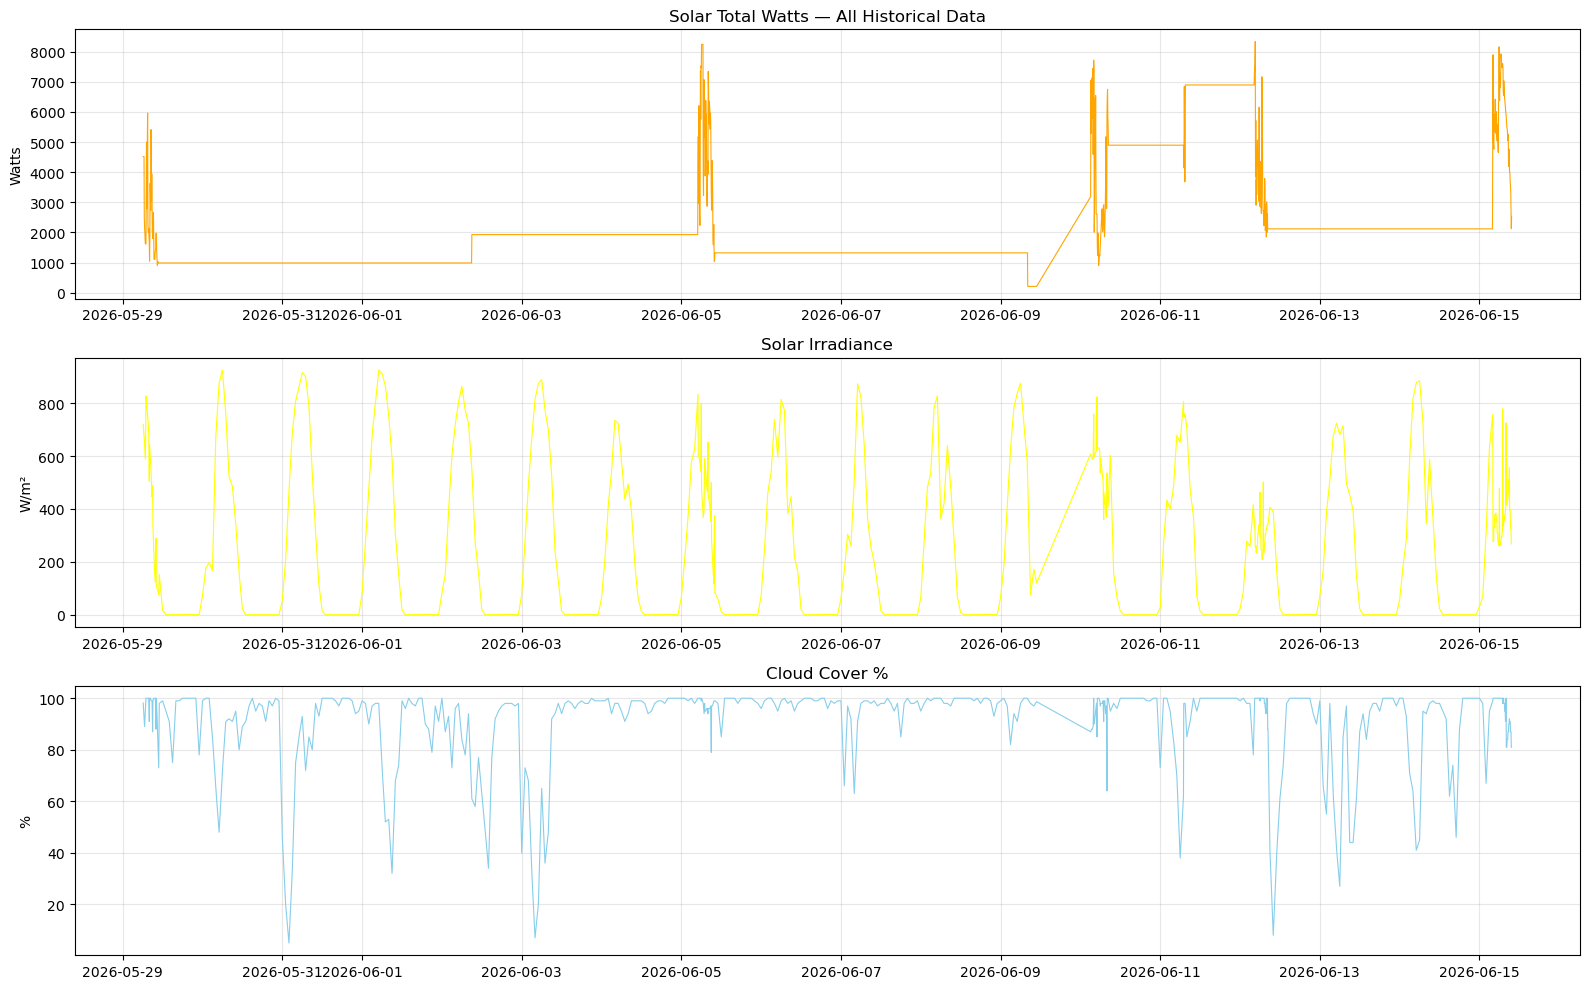

Max solar  : 8336 W
Mean solar : 2159 W
Min solar  : 212 W


In [12]:
# VISUALIZE DATA — SANITY CHECK

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Plot 1: Solar total watts
axes[0].plot(df.index, df["solar_total_watts"],
             color="orange", linewidth=0.8)
axes[0].set_title("Solar Total Watts — All Historical Data")
axes[0].set_ylabel("Watts")
axes[0].grid(True, alpha=0.3)

# Plot 2: Solar irradiance
axes[1].plot(df.index, df["solar_irradiance"],
             color="yellow", linewidth=0.8)
axes[1].set_title("Solar Irradiance")
axes[1].set_ylabel("W/m²")
axes[1].grid(True, alpha=0.3)

# Plot 3: Cloud cover
axes[2].plot(df.index, df["cloud_cover"],
             color="skyblue", linewidth=0.8)
axes[2].set_title("Cloud Cover %")
axes[2].set_ylabel("%")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max solar  : {df['solar_total_watts'].max():.0f} W")
print(f"Mean solar : {df['solar_total_watts'].mean():.0f} W")
print(f"Min solar  : {df['solar_total_watts'].min():.0f} W")

In [13]:
# DEFINE FEATURES AND TRAIN/TEST SPLIT

FEATURES = [

    # Current solar state
    "solar_total_watts",
    
    # Current weather
    "solar_irradiance",
    "cloud_cover",
    "ambient_temp",

    # Time
    "hour_sin",
    "hour_cos",
    "day_of_week",

    # Solar lag features
    "solar_lag_1",
    "solar_lag_2",
    "solar_lag_3",

    # Rolling averages
    "solar_roll_15m",
    "solar_roll_30m",

    # Weather lag features
    "irradiance_lag_1",
    "irradiance_lag_2",

    "cloud_lag_1",
    "cloud_lag_2"
]

TARGET = "target_solar_15min"

X = df[FEATURES]
y = df[TARGET]

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Total samples    : {len(df)}")
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

print("\nFeatures used:")
for i, f in enumerate(FEATURES, 1):
    print(f"{i:2d}. {f}")

Total samples    : 4745
Training samples : 3796
Test samples     : 949

Features used:
 1. solar_total_watts
 2. solar_irradiance
 3. cloud_cover
 4. ambient_temp
 5. hour_sin
 6. hour_cos
 7. day_of_week
 8. solar_lag_1
 9. solar_lag_2
10. solar_lag_3
11. solar_roll_15m
12. solar_roll_30m
13. irradiance_lag_1
14. irradiance_lag_2
15. cloud_lag_1
16. cloud_lag_2


In [14]:
# TRAIN MODEL

model = GradientBoostingRegressor(
    n_estimators=200,    # number of trees
    max_depth=2,         # depth of each tree
    learning_rate=0.05,  # contribution of each tree
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained")
print(f"\nModel type     : {type(model).__name__}")
print(f"Trees built    : {model.n_estimators_}")
print(f"Features used  : {len(FEATURES)}")

Model trained

Model type     : GradientBoostingRegressor
Trees built    : 200
Features used  : 16


In [15]:
# EVALUATE MODEL — METRICS

preds = model.predict(X_test)
preds = np.clip(preds, 0, None)  # no negative solar

from sklearn.metrics import r2_score

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
error_pct = (mae / y_test.mean() * 100)

# Format metrics as clean table
print("\nMODEL PERFORMANCE METRICS\n")
print(f"  MAE (Mean Absolute Error)       {mae:>10.1f} W")
print(f"  RMSE (Root Mean Squared Error)  {rmse:>10.1f} W")
print(f"  R² (R-Squared)                  {r2:>10.3f}")
print(f"  Mean Actual Solar Power         {y_test.mean():>10.1f} W")
print(f"  Error as % of Mean              {error_pct:>10.1f}%")

print("\nRESULT INTERPRETATION:")
if error_pct < 10:
    print(" EXCELLENT — Error < 10% of mean solar power")
elif error_pct < 20:
    print(" GOOD — Error < 20% of mean solar power")
elif error_pct < 30:
    print(" ACCEPTABLE — Error < 30%, more data will improve this")
else:
    print(" NEEDS IMPROVEMENT — Error ≥ 30%, collect more data")


MODEL PERFORMANCE METRICS

  MAE (Mean Absolute Error)            276.0 W
  RMSE (Root Mean Squared Error)       567.5 W
  R² (R-Squared)                       0.799
  Mean Actual Solar Power             2562.2 W
  Error as % of Mean                    10.8%

RESULT INTERPRETATION:
 GOOD — Error < 20% of mean solar power


In [16]:
# DATA VERIFICATION — RAW vs RESAMPLED

print("RESAMPLED DATA (5-min) — first 3 rows of test set\n")

df_compare = X_test.copy()
df_compare["actual_data"]   = X_test["solar_total_watts"]
df_compare["predicted_data"] = preds

df_compare_display = df_compare[["actual_data", "predicted_data"]].head(3).copy()
df_compare_display["UTC Time"]      = df_compare_display.index.strftime("%Y-%m-%d %H:%M:%S ")
df_compare_display["Thailand Time"] = (
    df_compare_display.index
    .tz_convert("Asia/Bangkok")
    .strftime("%Y-%m-%d %H:%M:%S")
)
print(df_compare_display[
    ["UTC Time", "Thailand Time", "actual_data", "predicted_data"]
].to_string(index=False, col_space=20))


# RESAMPLING WINDOW VERIFICATION (first resampled row)

first_ts     = df_compare_display.index[0]       # e.g. 12:55:00 UTC 
win_start    = first_ts
win_end      = first_ts + pd.Timedelta("5min")
first_actual = df_compare_display["actual_data"].iloc[0]


print("\n\nRESAMPLING WINDOW VERIFICATION (first resampled row)")
# print(f"  Resampled label  : {first_ts.strftime('%Y-%m-%d %H:%M:%S UTC')} "
#       f"({first_ts.tz_convert('Asia/Bangkok').strftime('%H:%M:%S')} TH)")
# print(f"  Window searched  : {win_start.strftime('%H:%M:%S')} → "
#       f"{(win_end - pd.Timedelta('1s')).strftime('%H:%M:%S')} UTC")
# print(f"  Resampled value  : {first_actual:.1f} W")

df_raw_window = df_solar_raw[
    (df_solar_raw["_time"] >= win_start) &
    (df_solar_raw["_time"] <  win_end)
].copy()

if df_raw_window.empty:
    print(f"\n  No raw readings found in this window")
    print(f"   slot was NaN; value carried forward by ffill(limit=2)")
else:
    df_raw_window["raw_total"] = (
        df_raw_window["ac_power_phase_a"] +
        df_raw_window["ac_power_phase_b"] +
        df_raw_window["ac_power_phase_c"]
    )
    df_raw_window["UTC Time"]      = df_raw_window["_time"].dt.strftime("%Y-%m-%d %H:%M:%S ")
    df_raw_window["Thailand Time"] = (
        df_raw_window["_time"]
        .dt.tz_convert("Asia/Bangkok")
        .dt.strftime("%Y-%m-%d %H:%M:%S")
    )

    disp_win = df_raw_window[[
        "UTC Time", "Thailand Time",
        "ac_power_phase_a", "ac_power_phase_b", "ac_power_phase_c",
        "raw_total"
    ]].rename(columns={
        "ac_power_phase_a": "Phase A (W)",
        "ac_power_phase_b": "Phase B (W)",
        "ac_power_phase_c": "Phase C (W)",
        "raw_total": "Sum (W)"
    })

    table_str = disp_win.to_string(index=False)
    sep       = "─" * len(table_str.splitlines()[0])

    print(f"Raw readings in window:")
    print(table_str)

    window_mean = df_raw_window["raw_total"].mean()
    n           = len(df_raw_window)
    print(sep)
    print(f"  Window mean ({n} row{'s' if n != 1 else ''})    : {window_mean:.1f} W")
    print(f"  Resampled actual_data : {first_actual:.1f} W")



RESAMPLED DATA (5-min) — first 3 rows of test set

            UTC Time        Thailand Time          actual_data       predicted_data
2026-06-12 02:40:00   2026-06-12 09:40:00            6896.3075          6870.182287
2026-06-12 02:45:00   2026-06-12 09:45:00            6896.3075          6870.182287
2026-06-12 02:50:00   2026-06-12 09:50:00            6896.3075          6870.182287


RESAMPLING WINDOW VERIFICATION (first resampled row)

  No raw readings found in this window
   slot was NaN; value carried forward by ffill(limit=2)


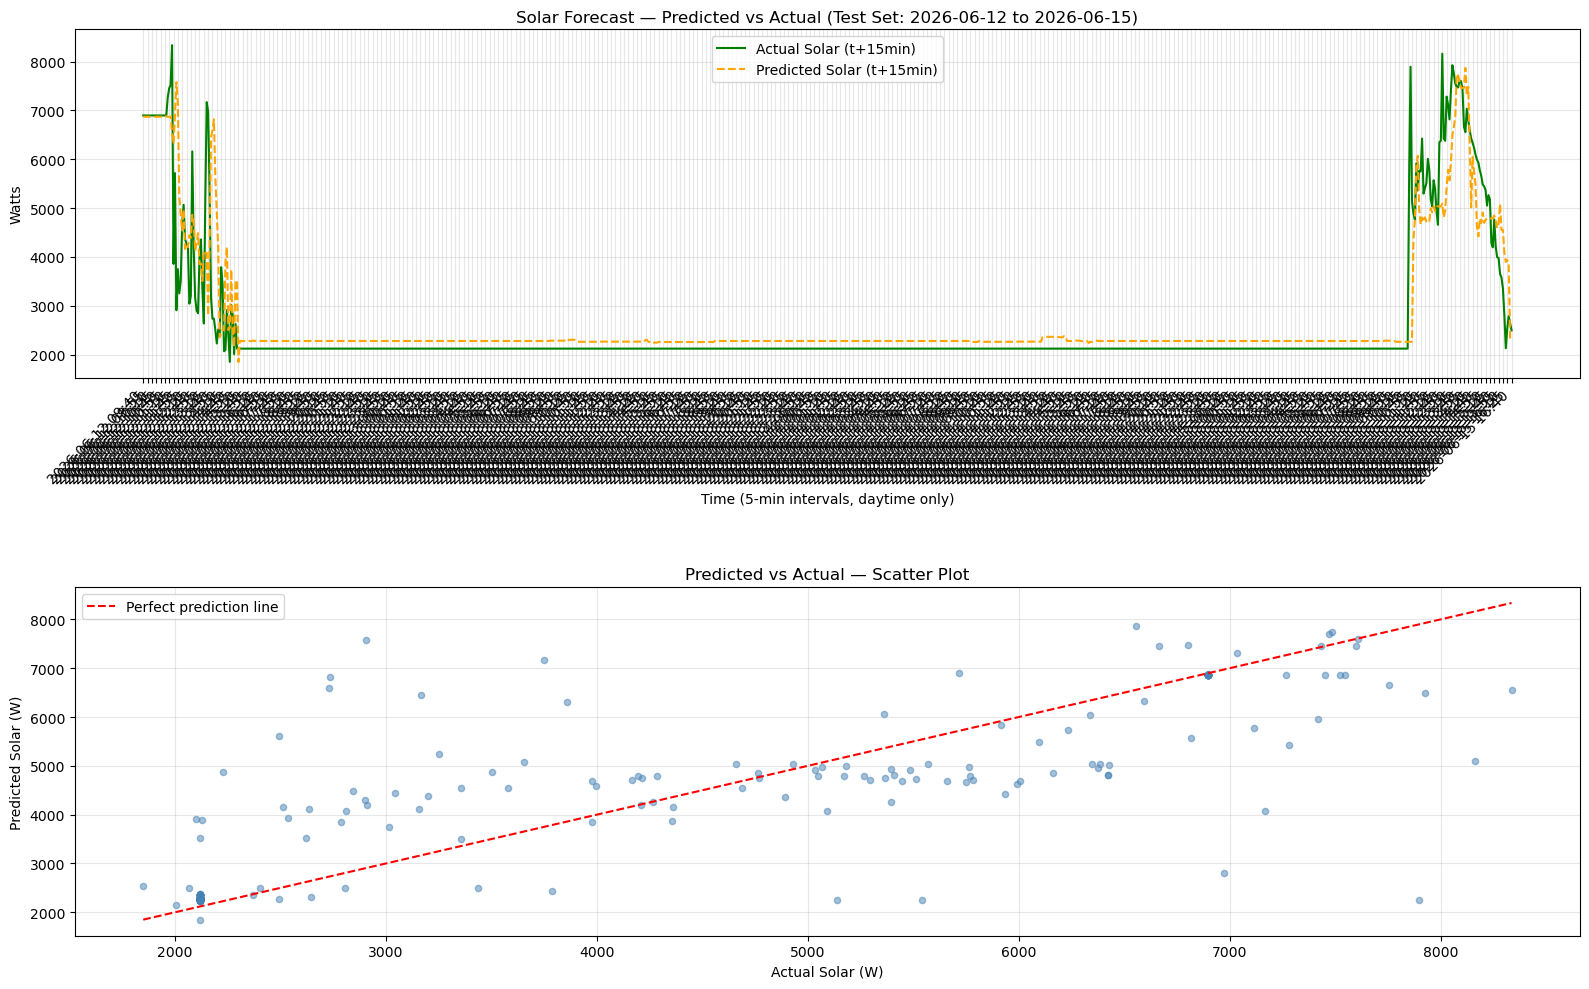

In [17]:
# PLOT PREDICTED VS ACTUAL

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Get timestamp labels at regular intervals (every 3 steps = 15 min)
step_interval = 3  # every 15 minutes
x_positions = range(0, len(y_test), step_interval)
x_labels = [y_test.index[i].tz_convert('Asia/Bangkok').strftime('%Y-%m-%d %H:%M') 
            for i in x_positions]

# Date range for title
date_start = y_test.index[0].tz_convert('Asia/Bangkok').strftime('%Y-%m-%d')
date_end = y_test.index[-1].tz_convert('Asia/Bangkok').strftime('%Y-%m-%d')

# Plot 1: Full test set (skip nighttime gaps)
axes[0].plot(range(len(y_test)), y_test.values,
             label="Actual Solar (t+15min)",
             color="green", linewidth=1.5)
axes[0].plot(range(len(preds)), preds,
             label="Predicted Solar (t+15min)",
             color="orange", linestyle="--", linewidth=1.5)
axes[0].set_title(f"Solar Forecast — Predicted vs Actual (Test Set: {date_start} to {date_end})")
axes[0].set_xlabel("Time (5-min intervals, daytime only)")
axes[0].set_ylabel("Watts")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Scatter plot — perfect prediction would be diagonal line
axes[1].scatter(y_test.values, preds, 
                alpha=0.5, color="steelblue", s=20)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color="red", linestyle="--", linewidth=1.5,
             label="Perfect prediction line")
axes[1].set_title("Predicted vs Actual — Scatter Plot")
axes[1].set_xlabel("Actual Solar (W)")
axes[1].set_ylabel("Predicted Solar (W)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# Add proper spacing between subplots
plt.tight_layout()
plt.subplots_adjust(hspace=0.6)  # extra vertical gap between the two plots
plt.show()
# plt.tight_layout()
#     print(f"\n  NO raw readings found in {win_start.strftime('%H:%M')} → {(win_end - pd.Timedelta('1s')).strftime('%H:%M')} UTC")    print(f"  ➜ This slot was NaN in resampled grid")    print(f"  ➜ Value was CARRIED FORWARD by ffill(limit=2) from earlier\n")        # Find where the actual value came from by looking backward    print(f"  Searching backward to find source of {first_actual:.1f} W...")        # Look 1-4 windows back (5-20 minutes earlier)    found = False    for steps_back in range(1, 5):        prev_win_end = win_start        prev_win_start = prev_win_end - pd.Timedelta(f"{5*steps_back}min")                df_prev_window = df_solar_raw[            (df_solar_raw["_time"] >= prev_win_start) &            (df_solar_raw["_time"] <  prev_win_end)        ].copy()                if not df_prev_window.empty:            df_prev_window["raw_total"] = (                df_prev_window["solar_string_1_power_watts"] +                df_prev_window["solar_string_2_power_watts"]            )            prev_mean = df_prev_window["raw_total"].mean()                        print(f"\n  → {5*steps_back} min earlier ({prev_win_start.strftime('%H:%M:%S')} → {(prev_win_end - pd.Timedelta('1s')).strftime('%H:%M:%S')} UTC):")            print(f"     Mean of {len(df_prev_window)} raw points: {prev_mean:.1f} W")                        if abs(prev_mean - first_actual) < 1.0:                print(f"     ✅ MATCH! — This is where {first_actual:.1f} W came from")                found = True                                # Show these raw points                df_prev_window["UTC Time"]      = df_prev_window["_time"].dt.strftime("%Y-%m-%d %H:%M:%S UTC")                df_prev_window["Thailand Time"] = (                    df_prev_window["_time"]                    .dt.tz_convert("Asia/Bangkok")                    .dt.strftime("%Y-%m-%d %H:%M:%S")                )                                disp_prev = df_prev_window[[                    "UTC Time", "Thailand Time",                    "solar_string_1_power_watts", "solar_string_2_power_watts",                    "raw_total"                ]].rename(columns={                    "solar_string_1_power_watts": "String 1 (W)",                    "solar_string_2_power_watts": "String 2 (W)",                    "raw_total": "Sum (W)"                })                                print(f"\n     Raw data points that created this resampled value:")                print(disp_prev.to_string(index=False))                break        if not found:        print(f"\n  Could not find source within 20 minutes back")else:    df_raw_window["raw_total"] = (        df_raw_window["solar_string_1_power_watts"] +        df_raw_window["solar_string_2_power_watts"]    )    df_raw_window["UTC Time"]      = df_raw_window["_time"].dt.strftime("%Y-%m-%d %H:%M:%S UTC")    df_raw_window["Thailand Time"] = (        df_raw_window["_time"]        .dt.tz_convert("Asia/Bangkok")        .dt.strftime("%Y-%m-%d %H:%M:%S")    )    disp_win = df_raw_window[[        "UTC Time", "Thailand Time",        "solar_string_1_power_watts", "solar_string_2_power_watts",        "raw_total"    ]].rename(columns={        "solar_string_1_power_watts": "String 1 (W)",        "solar_string_2_power_watts": "String 2 (W)",        "raw_total": "Sum (W)"    })    table_str = disp_win.to_string(index=False)    sep       = "─" * len(table_str.splitlines()[0])    print(f"\nRaw readings in window:")    print(table_str)    window_mean = df_raw_window["raw_total"].mean()    n           = len(df_raw_window)
#     print(sep)
#     print(f"  Window mean ({n} row{'s' if n != 1 else ''})    : {window_mean:.1f} W")
#     print(f"  Resampled actual_data : {first_actual:.1f} W")


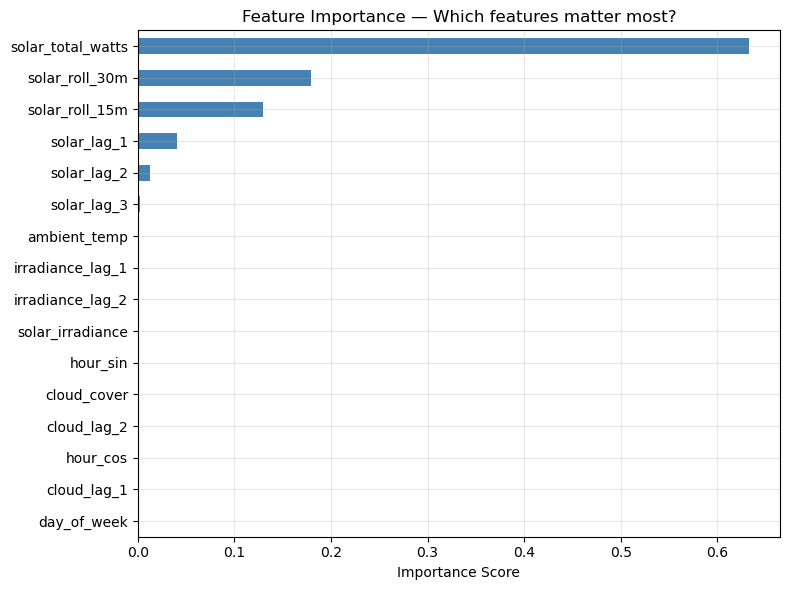


Feature importance ranked (highest first):
────────────────────────────────────────
solar_total_watts         0.6332  ███████████████████████████████████████████████████████████████
solar_roll_30m            0.1795  █████████████████
solar_roll_15m            0.1302  █████████████
solar_lag_1               0.0402  ████
solar_lag_2               0.0125  █
solar_lag_3               0.0021  
ambient_temp              0.0010  
irradiance_lag_1          0.0007  
irradiance_lag_2          0.0002  
solar_irradiance          0.0002  
hour_sin                  0.0001  
cloud_cover               0.0001  
cloud_lag_2               0.0001  
hour_cos                  0.0000  
cloud_lag_1               0.0000  
day_of_week               0.0000  


In [18]:
# FEATURE IMPORTANCE

importance = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values()

importance.plot(
    kind="barh",
    figsize=(8, 6),
    color="steelblue"
)
plt.title("Feature Importance — Which features matter most?")
plt.xlabel("Importance Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFeature importance ranked (highest first):")
print("─" * 40)
for feat, score in importance.sort_values(ascending=False).items():
    bar = "█" * int(score * 100)
    print(f"{feat:<25} {score:.4f}  {bar}")

In [ ]:
# SAVE MODEL

import os

# Save model
model_path = "solar_forecast_model_phase1.pkl"
joblib.dump(model, model_path)

# Verify saved correctly
loaded_model = joblib.load(model_path)
test_pred    = loaded_model.predict(X_test[:1])

print(f"Model saved as   : {model_path}")
print(f"File size        : {os.path.getsize(model_path) / 1024:.1f} KB")
print(f"Verify load test : {test_pred[0]:.1f} W predicted")
print()
print("Phase 1 complete")
print("─" * 40)
print(f"Model type       : GradientBoostingRegressor")
print(f"Features         : {len(FEATURES)}")
print(f"Training rows    : {len(X_train)}")
print(f"MAE              : {mae:.1f} W")
print(f"Error %          : {(mae/y_test.mean()*100):.1f}%")
print()
print("Next step: Collect more data → retrain as Phase 2")
print("          with forecast weather features added")